In [1]:
import pandas as pd


In [2]:
df = pd.read_csv('twitter_training.csv')
val_df = pd.read_csv('twitter_validation.csv')

In [3]:
df1 = df.copy()

In [4]:
df1.sentiment.value_counts()

sentiment
Negative      22357
Positive      20653
Neutral       18105
Irrelevant    12875
Name: count, dtype: int64

In [5]:
# %pip install spacy
# !python -m spacy download en_core_web_lg

import spacy
nlp = spacy.load("en_core_web_lg", disable=["parser", "ner"])

In [6]:
%pip install contractions emoji


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [7]:
import contractions
import re
import emoji
from bs4 import BeautifulSoup

def preprocess_text(text):
    # Converts emoji to text
    text = emoji.demojize(text)
    text = BeautifulSoup(text, "html.parser").get_text() # Remove HTML tags
    
    text = contractions.fix(text)  # Expand contractions
    text = text.lower()  # Convert to lowercase
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)  # Remove URLs
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)  # Reduce repeated characters
    text=re.sub(r"[@#^<>|(){}[\]\~*+=]", " ", text) # Remove less important special characters
    text=re.sub(r"\s+", " ", text)
    text = text.strip()  # Remove leading and trailing spaces
    return text

In [8]:
df1['tweet_content'] = df1['tweet_content'].apply(lambda x: preprocess_text(x))
val_df['tweet_content'] = val_df['tweet_content'].apply(lambda x: preprocess_text(x))

/tmp/ipykernel_4126/142434363.py:9: MarkupResemblesLocatorWarning: The input passed in on this line looks more like a filename than HTML or XML.

If you meant to use Beautiful Soup to parse the contents of a file on disk, then something has gone wrong. You should open the file first, using code like this:

    filehandle = open(your filename)

You can then feed the open filehandle into Beautiful Soup instead of using the filename.

However, if you want to parse some data that happens to look like a filename, then nothing has gone wrong: you are using Beautiful Soup correctly, and this warning is spurious and can be filtered. To make this warning go away, run this code before calling the BeautifulSoup constructor:

    from bs4 import MarkupResemblesLocatorWarning
    import warnings

    warnings.filterwarnings("ignore", category=MarkupResemblesLocatorWarning)
    
  text = BeautifulSoup(text, "html.parser").get_text() # Remove HTML tags


In [9]:
def check_for_only_spaces_or_punctuations(text):
    # Check if the text contains only spaces or punctuation
    if not text or text.isspace() or re.match(r'^[\W_]+$', text):
        return True
    
    doc = nlp(text)
    
    if all (token.is_punct or token.is_space for token in doc):
        return True
    
    return False

In [10]:
df1['status'] = df1['tweet_content'].apply(check_for_only_spaces_or_punctuations)

In [11]:
df1.drop(df1[df1['status'] == True].index, inplace=True)

In [137]:
df1

,tID,entity,sentiment,tweet_content,status
0,2401,Borderlands,Positive,i am coming to the borders and i will kill you...,False
1,2401,Borderlands,Positive,i am getting on borderlands and i will kill yo...,False
2,2401,Borderlands,Positive,i am coming on borderlands and i will murder y...,False
3,2401,Borderlands,Positive,i am getting on borderlands 2 and i will murde...,False
4,2401,Borderlands,Positive,i am getting into borderlands and i can murder...,False
...,...,...,...,...,...
73985,9200,Nvidia,Positive,just realized that the windows partition of my...,False
73986,9200,Nvidia,Positive,just realized that my mac window partition is ...,False
73987,9200,Nvidia,Positive,just realized the windows partition of my mac ...,False
73988,9200,Nvidia,Positive,just realized between the windows partition of...,False


In [12]:
df1.drop(columns=['status','tID'], inplace=True)

In [13]:
df1.drop_duplicates(inplace=True)

In [14]:
df1.reset_index(drop=True, inplace=True)

In [15]:
val_df.drop(columns=['ID'], inplace=True)

In [16]:
df = df1.copy()

In [160]:
df.shape

(69382, 3)

In [161]:
def remove_stopword(text):
    doc = nlp(text)
    filtered_tokens = [token.text for token in doc if not token.is_stop]
    return " ".join(filtered_tokens)

In [145]:
df['stopword_text'] =df['tweet_content'].apply(remove_stopword)



In [158]:
df['stopword_text']

0                                    coming borders kill ,
1                               getting borderlands kill ,
2                              coming borderlands murder ,
3                           getting borderlands 2 murder ,
4                             getting borderlands murder ,
                               ...                        
69377    realized windows partition mac like 6 years nv...
69378    realized mac window partition 6 years nvidia d...
69379    realized windows partition mac 6 years nvidia ...
69380    realized windows partition mac like 6 years nv...
69381    like windows partition mac like 6 years driver...
Name: stopword_text, Length: 69382, dtype: object

In [240]:
def lem(text_col, cat_col, data):
    data[text_col]=data[cat_col].astype(str)+" "+data[text_col].astype(str) # Concatenate the 'games' column content with the 'tweets' column content
    lemm=[" ".join([token.lemma_ for token in doc]) for doc in nlp.pipe(data[text_col], batch_size=256, n_process=-1)] # Perform lemmatization using spaCy's nlp.pipe for efficient batch processing
    return pd.Series(lemm, index=data.index)



In [17]:
def lemmatize_texts(texts, data):
    data[texts] = data[texts].astype(str)
    lemmatized = [
        " ".join(token.lemma_ for token in doc)
        for doc in nlp.pipe(data[texts], batch_size=256, n_process=-1)
    ]
    return pd.Series(lemmatized, index=data.index)




In [18]:
df['lemmatized_text']  = lemmatize_texts('tweet_content', df)

In [19]:
val_df['lemmatized_text']  = lemmatize_texts('tweet_content', val_df)

In [238]:
df['lemmatized_text']

0        I be come to the border and I will kill you all ,
1         I be get on borderland and I will kill you all ,
2        I be come on borderland and I will murder you ...
3        I be get on borderland 2 and I will murder you...
4        I be get into borderland and I can murder you ...
                               ...                        
69377    just realize that the window partition of my m...
69378    just realize that my mac window partition be 6...
69379    just realize the window partition of my mac be...
69380    just realize between the window partition of m...
69381    just like the window partition of my mac be li...
Name: lemmatized_text, Length: 69382, dtype: object

In [20]:
def tokenize(text):
    tokens = []
    for token in nlp(text.lower()):
        tokens.append(token.text)
    return tokens

In [21]:
df['tokenized_text'] = df['lemmatized_text'].apply(tokenize)

In [22]:
val_df['tokenized_text'] = val_df['lemmatized_text'].apply(tokenize)

In [207]:
def lem_single(text):
    doc = nlp(text)
    return " ".join(token.lemma_ for token in doc)


In [23]:
from collections import Counter

def word_occurrence(df):
    sentences = []
    for _ , row in df.iterrows():
        text = row['tokenized_text']   
       
        sentences.extend(text)
    
    vocab = {'<unk>': 0}
    
    for token in Counter(sentences):
        if token not in vocab:
            vocab[token] = len(vocab)
    
    return vocab
    
        

In [24]:
vocab = word_occurrence(df)

In [25]:
def replace_word_with_numbers(text):
    tokens = []
    for token in text:
        if token in vocab:
            tokens.append(vocab[token])
        else:
            tokens.append(vocab['<unk>'])
    return tokens

In [26]:
df['tokenized_text_in_numbers'] = df['tokenized_text'].apply(replace_word_with_numbers)

In [27]:
val_df['tokenized_text_in_numbers'] = val_df['tokenized_text'].apply(replace_word_with_numbers)

In [213]:
def padding(text):
    max_len = 200
    if len(text) > max_len:
        max_len = len(text)
    return [text + [0] * (max_len - len(text)) ]

In [214]:
def text_pipeline(text):
    # The preprocess_text and lem functions expect string inputs, but the others expect list of string inputs
    processed_text = preprocess_text(text)
    lemmatized_text = lem_single(processed_text) # Wrap in list for lem and unwrap
    tokenized_text = tokenize(lemmatized_text)
    vocab = word_occurrence(df) # Using existing vocab here
    tokenized_numbers = replace_word_with_numbers(tokenized_text)
    print(tokenized_numbers)
    padded_numbers = padding(tokenized_numbers) # Wrap and unwrap for padding

    return padded_numbers

In [215]:
df['tokenized_text_in_numbers'].apply(padding)

0        [[1, 2, 3, 4, 5, 6, 7, 1, 8, 9, 10, 11, 12, 0,...
1        [[1, 2, 13, 14, 15, 7, 1, 8, 9, 10, 11, 12, 0,...
2        [[1, 2, 3, 14, 15, 7, 1, 8, 16, 10, 11, 12, 0,...
3        [[1, 2, 13, 14, 15, 17, 7, 1, 8, 16, 10, 1, 11...
4        [[1, 2, 13, 18, 15, 7, 1, 19, 16, 10, 11, 12, ...
                               ...                        
69377    [[268, 694, 57, 5, 6401, 33030, 38, 39, 1735, ...
69378    [[268, 694, 57, 39, 1735, 6401, 33030, 2, 194,...
69379    [[268, 694, 5, 6401, 33030, 38, 39, 1735, 2, 4...
69380    [[268, 694, 520, 5, 6401, 33030, 38, 39, 1735,...
69381    [[268, 92, 5, 6401, 33030, 38, 39, 1735, 2, 92...
Name: tokenized_text_in_numbers, Length: 69382, dtype: object

In [177]:
text_pipeline("Hello, I am happy to play game with you")

[2128, 12, 1, 2, 688, 4, 273, 318, 610, 10]


[[2128,
  12,
  1,
  2,
  688,
  4,
  273,
  318,
  610,
  10,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  

In [28]:
def padding(text):
    max_len = max(len(text) for text in df['tokenized_text_in_numbers'])
    return [text + [0] * (max_len - len(text)) for text in text]

In [29]:
df['tokenized_text_in_numbers'] = padding(df['tokenized_text_in_numbers'])

In [30]:
val_df['tokenized_text_in_numbers'] = padding(val_df['tokenized_text_in_numbers'])

In [31]:
X = df['tokenized_text_in_numbers']
y = df['sentiment']
X_val = val_df['tokenized_text_in_numbers']
y_val = val_df['sentiment']

In [32]:
df['sentiment'].value_counts()

sentiment
Negative      21033
Positive      19062
Neutral       17083
Irrelevant    12204
Name: count, dtype: int64

In [33]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y_lbl = label_encoder.fit_transform(y)

In [34]:
# Prepare the test data


y_val_lbl = label_encoder.transform(y_val)

In [184]:
y_lbl

array([3, 3, 3, ..., 3, 3, 3])

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y_lbl, random_state=42)

In [37]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weights = torch.tensor(class_weights, dtype=torch.float)
print(class_weights)


tensor([1.4056, 0.8245, 1.0181, 0.9145])


In [36]:
import torch
from torch import nn

device = "cuda" if torch.cuda.is_available() else "cpu"
device


'cuda'

In [38]:
from torch.utils.data import Dataset
import numpy as np

class NLPdataCustom(Dataset):
    
    def __init__(self, X_feature,y_label):
        
        # Convert to NumPy arrays first
        X_np = np.array(X_feature.tolist())  # Ensures 2D shape if Series contains lists
        y_np = np.array(y_label.tolist()) 
        
        
        self.X = torch.tensor(X_np ,dtype=torch.long)
        self.y = torch.tensor(y_np, dtype=torch.long)
        
        
    def __len__(self):
        return len(self.X)
    
    
    def __getitem__(self, index):
        X = self.X[index]
        y = self.y[index]
        
        return X, y
    



In [39]:
train_data_set = NLPdataCustom(X_train, y_train)
test_data_set = NLPdataCustom(X_test, y_test)
val_data_set = NLPdataCustom(X_val, y_val_lbl)

In [40]:
print("Unique labels:", train_data_set.y.unique())
print("Max label:", train_data_set.y.max().item())
print("Min label:", train_data_set.y.min().item())
print("Output classes expected:", len(train_data_set.y.unique()))


Unique labels: tensor([0, 1, 2, 3])
Max label: 3
Min label: 0
Output classes expected: 4


In [41]:
from torch.utils.data import DataLoader

BATCH_SIZE = 64

train_dataloader_custom = DataLoader(dataset=train_data_set,
                                     batch_size=BATCH_SIZE,
                                     shuffle=True,
                                     pin_memory=True)
                                    #  num_workers=1)

test_dataloader_custom = DataLoader(dataset=test_data_set,
                                    batch_size=BATCH_SIZE,
                                    pin_memory=True,
                                    shuffle=False)

val_dataloader_custom = DataLoader(dataset=val_data_set,
                                    batch_size=BATCH_SIZE,
                                    pin_memory=True,
                                    shuffle=False)

In [42]:
class LSTMModelV1(nn.Module):

    def __init__(self, input_size, embedding_dim, hidden_size, layer_dim, drop_out, bi_directional , output_dim):
        super().__init__()
        self.hidden_size = hidden_size
        self.layer_dim = layer_dim
        self.embedding = nn.Embedding(input_size, embedding_dim=embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_size, batch_first=True, num_layers=layer_dim, bidirectional=bi_directional, dropout=drop_out)
        self.batch = nn.BatchNorm1d(hidden_size * 2 if bi_directional else hidden_size, output_dim)
        self.dropout = nn.Dropout(drop_out)
        self.linear = nn.Linear(hidden_size * 2 if bi_directional else hidden_size, output_dim) # Adjust linear layer size based on bidirectionality
        self.bi_directional = bi_directional


    def forward(self, x):

        num_directions = 2 if self.bi_directional else 1
        h0 = torch.zeros(self.layer_dim * num_directions, x.size(0), self.hidden_size , device=device).requires_grad_()
        c0 = torch.zeros(self.layer_dim * num_directions, x.size(0), self.hidden_size, device=device).requires_grad_()
        embedding = self.embedding(x)
        output ,(hidden, cell) = self.lstm(embedding, (h0.detach(), c0.detach()))

        if self.bi_directional:
             # hidden[-2,:,:] corresponds to the last layer's forward hidden state
            # hidden[-1,:,:] corresponds to the last layer's backward hidden state

            hidden_combined = self.dropout(self.batch(torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)))
        else:
            hidden_combined = self.dropout(self.batch(hidden[-1,:,:])) # Use only the last layer's hidden state for unidirectional LSTM

        # hidden_combined: (batch_size, hidden_dim * 2)

        # Pass through fully connected layer to get the final prediction
        out =  self.linear(hidden_combined)

        return out

In [43]:
def train_step(model,
               dataloader,
               loss_fn,
               optimizer,
               device):



    model.train()

    train_loss, train_acc = 0, 0

    for batch, (X,y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        # 1. Forward propagation
        y_pred = model(X)

        # 2. Calculate and accumulate loss
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        # 3. optimizer zero grad
        optimizer.zero_grad()

        # 4. loss backward
        loss.backward()

        # 5. optimizer step
        optimizer.step()

        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item() / len(y_pred)


    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)


    return train_loss, train_acc



In [44]:
def test_step(model,
              dataloader,
              loss_fn,
              device):



    model.eval()

    test_loss, test_acc = 0, 0


    with torch.inference_mode():
        for batch , (X,y) in enumerate(dataloader):
            X, y = X.to(device), y.to(device)

            test_pred_logits = model(X)

            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()

            test_pred_labels = test_pred_logits.argmax(dim=1)

            test_acc += ((test_pred_labels == y).sum().item() / len(test_pred_labels))



    test_loss = test_loss / len(dataloader)

    test_acc = test_acc / len(dataloader)


    return test_loss, test_acc



In [45]:
from tqdm.auto import tqdm


def train(model,
          train_dataloader,
          test_dataloader,
          loss_fn,
          optimizer,
          epochs,
          device):


    results = {"train_loss": [],
               "train_acc": [],
               "test_loss":[],
               "test_acc":[]}


    for epoch in tqdm(range(epochs)):
        train_loss, train_acc = train_step(model,
                                           train_dataloader,
                                           loss_fn,
                                           optimizer,
                                           device)


        test_loss, test_acc = test_step(model,
                                        test_dataloader,
                                        loss_fn,
                                        device)


        print(f"Epoch: {epoch+1} |  Train loss: {train_loss:.4f} | Train acc: {train_acc:.4f} | Test loss: {test_loss:.4f} | Test acc: {test_acc:.4f}" )

        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["test_loss"].append(test_loss)
        results["test_acc"].append(test_acc)

    return results

In [52]:
!pip install mlflow


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [53]:
import mlflow

# The set_experiment API creates a new experiment if it doesn't exist.
mlflow.set_experiment("Hyperparameter Tuning Experiment")

2026/01/12 09:20:19 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/01/12 09:20:19 INFO mlflow.store.db.utils: Updating database tables
2026/01/12 09:20:19 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/01/12 09:20:19 INFO alembic.runtime.migration: Will assume non-transactional DDL.
2026/01/12 09:20:20 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/01/12 09:20:20 INFO alembic.runtime.migration: Will assume non-transactional DDL.


<Experiment: artifact_location='/teamspace/studios/this_studio/mlruns/1', creation_time=1768137701190, experiment_id='1', last_update_time=1768137701190, lifecycle_stage='active', name='Hyperparameter Tuning Experiment', tags={}>

In [57]:
def objective(trial):

    with mlflow.start_run(nested=True, run_name=f"trial_{trial.number}") as child_run:

        # -------------------------------
        # Hyperparameters
        # -------------------------------
        num_hidden_layers = trial.suggest_int("num_hidden_layers", 1, 5)
        num_hidden_units = trial.suggest_int("num_hidden_units", 8, 128, step=8)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 0.5, step=0.1)
        learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-1, log=True)
        epoch_num = trial.suggest_int("epoch_num", 10, 50, step=10)
        batch_size = trial.suggest_int("batch_size", 32, 128, step=32)
        bi_directional = trial.suggest_categorical("bi_directional", [True, False])
        optimizer_name = trial.suggest_categorical("optimizer", ["Adam", "RMSprop","AdamW"])
        weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-3, log=True)

        params = {
            "num_hidden_layers": num_hidden_layers,
            "num_hidden_units": num_hidden_units,
            "dropout_rate": dropout_rate,
            "learning_rate": learning_rate,
            "epoch_num": epoch_num,
            "batch_size": batch_size,
            "bi_directional": bi_directional,
            "optimizer": optimizer_name,
            "weight_decay": weight_decay
        }

        mlflow.log_params(params)

        # -------------------------------
        # Model
        # -------------------------------
        model = LSTMModelV1(
            input_size=len(vocab),
            embedding_dim=100,
            hidden_size=num_hidden_units,
            layer_dim=num_hidden_layers,
            drop_out=dropout_rate,
            bi_directional=bi_directional,
            output_dim=len(train_data_set.y.unique())
        ).to(device)

        # -------------------------------
        # DataLoaders
        # -------------------------------
        train_dataloader = DataLoader(
            train_data_set,
            batch_size=batch_size,
            shuffle=True,
            pin_memory=True
        )

        test_dataloader = DataLoader(
            test_data_set,
            batch_size=batch_size,
            shuffle=False,
            pin_memory=True
        )

        loss_fn = nn.CrossEntropyLoss()

        if optimizer_name == "Adam":
            optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
        elif optimizer_name == "RMSprop":
            optimizer = torch.optim.RMSprop(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
        else:
            optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

        # -------------------------------
        # Train
        # -------------------------------
        model_results = train(
            model=model,
            train_dataloader=train_dataloader,
            test_dataloader=test_dataloader,
            optimizer=optimizer,
            loss_fn=loss_fn,
            epochs=epoch_num,
            device=device
        )

        # -------------------------------
        # SAFE metric extraction
        # -------------------------------
        train_loss = model_results["train_loss"][-1]
        test_loss = model_results["test_loss"][-1]
        train_acc = model_results["train_acc"][-1]
        test_acc = model_results["test_acc"][-1]

        # Skip bad trials
        if any(map(lambda x: x != x, [train_loss, test_loss, train_acc, test_acc])):
            return 0.0

        # -------------------------------
        # Log metrics WITH step
        # -------------------------------
        mlflow.log_metrics(
            {
                "train_loss": train_loss,
                "train_acc": train_acc,
                "test_loss": test_loss,
                "test_acc": test_acc
            },
            step=epoch_num   # ✅ CRITICAL FIX
        )

        # -------------------------------
        # Correct PyTorch logging
        # -------------------------------
        mlflow.pytorch.log_model(model, artifact_path="model")

        trial.set_user_attr("run_id", child_run.info.run_id)

        return test_acc


In [55]:
import optuna

study = optuna.create_study(direction='maximize')

[I 2026-01-12 09:20:27,349] A new study created in memory with name: no-name-bb670979-ca71-4b07-bc5d-9903e2dd764e


In [58]:
# Create a parent run that contains all child runs
with mlflow.start_run(run_name="study") as parent_run:

    n_trials = 20
    mlflow.log_param("n_trials", n_trials)

    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=n_trials)

    # -------------------------------
    # Log best trial info SAFELY
    # -------------------------------
    mlflow.log_params(study.best_trial.params)

    mlflow.log_metrics(
        {
            "best_accuracy": study.best_value
        },
        step=n_trials   # ✅ VERY IMPORTANT
    )

    # Store best child run id
    best_run_id = study.best_trial.user_attrs.get("run_id")
    if best_run_id:
        mlflow.log_param("best_child_run_id", best_run_id)


[I 2026-01-12 11:08:35,786] A new study created in memory with name: no-name-93cacc07-fe12-4484-9ffc-b0dc3dadc403


  0%|          | 0/50 [00:00<?, ?it/s]

Epoch: 1 |  Train loss: 1.3184 | Train acc: 0.3789 | Test loss: 1.2373 | Test acc: 0.4658
Epoch: 2 |  Train loss: 1.1855 | Train acc: 0.4941 | Test loss: 1.1309 | Test acc: 0.5253
Epoch: 3 |  Train loss: 1.0943 | Train acc: 0.5450 | Test loss: 1.0861 | Test acc: 0.5546
Epoch: 4 |  Train loss: 1.0317 | Train acc: 0.5775 | Test loss: 1.0335 | Test acc: 0.5736
Epoch: 5 |  Train loss: 0.9797 | Train acc: 0.6024 | Test loss: 1.0029 | Test acc: 0.5831
Epoch: 6 |  Train loss: 0.9339 | Train acc: 0.6213 | Test loss: 0.9676 | Test acc: 0.6014
Epoch: 7 |  Train loss: 0.8897 | Train acc: 0.6423 | Test loss: 0.9508 | Test acc: 0.6148
Epoch: 8 |  Train loss: 0.8519 | Train acc: 0.6613 | Test loss: 0.9250 | Test acc: 0.6246
Epoch: 9 |  Train loss: 0.8146 | Train acc: 0.6788 | Test loss: 0.8813 | Test acc: 0.6452
Epoch: 10 |  Train loss: 0.7796 | Train acc: 0.6942 | Test loss: 0.8963 | Test acc: 0.6430
Epoch: 11 |  Train loss: 0.7484 | Train acc: 0.7089 | Test loss: 0.8414 | Test acc: 0.6710
Epoch: 1

2026/01/12 11:27:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/01/12 11:27:38 WARNING mlflow.utils.requirements_utils: Found torch version (2.7.1+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.7.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


Epoch: 50 |  Train loss: 0.1822 | Train acc: 0.9379 | Test loss: 0.6629 | Test acc: 0.8169


...

  0%|          | 0/40 [00:00<?, ?it/s]

Epoch: 1 |  Train loss: 1.1586 | Train acc: 0.4999 | Test loss: 1.0225 | Test acc: 0.5884
Epoch: 2 |  Train loss: 0.8933 | Train acc: 0.6430 | Test loss: 0.8280 | Test acc: 0.6766
Epoch: 3 |  Train loss: 0.6491 | Train acc: 0.7593 | Test loss: 0.6832 | Test acc: 0.7515
Epoch: 4 |  Train loss: 0.4655 | Train acc: 0.8347 | Test loss: 0.6194 | Test acc: 0.7893
Epoch: 5 |  Train loss: 0.3487 | Train acc: 0.8780 | Test loss: 0.5422 | Test acc: 0.8174
Epoch: 6 |  Train loss: 0.2729 | Train acc: 0.9044 | Test loss: 0.5271 | Test acc: 0.8340
Epoch: 7 |  Train loss: 0.2264 | Train acc: 0.9220 | Test loss: 0.4998 | Test acc: 0.8400
Epoch: 8 |  Train loss: 0.2001 | Train acc: 0.9304 | Test loss: 0.4989 | Test acc: 0.8522
Epoch: 9 |  Train loss: 0.1762 | Train acc: 0.9383 | Test loss: 0.5268 | Test acc: 0.8416
Epoch: 10 |  Train loss: 0.1601 | Train acc: 0.9438 | Test loss: 0.5792 | Test acc: 0.8289
Epoch: 11 |  Train loss: 0.1468 | Train acc: 0.9487 | Test loss: 0.4760 | Test acc: 0.8627
Epoch: 1

2026/01/12 13:34:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/01/12 13:34:03 WARNING mlflow.utils.requirements_utils: Found torch version (2.7.1+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.7.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


Epoch: 40 |  Train loss: 0.0769 | Train acc: 0.9719 | Test loss: 0.5513 | Test acc: 0.8644


2026/01/12 13:34:14 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.22.1+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torchvision==0.22.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
[I 2026-01-12 13:34:14,258] Trial 19 finished with value: 0.8644005542557932 and parameters: {'num_hidden_layers': 4, 'num_hidden_units': 96, 'dropout_rate': 0.30000000000000004, 'learning_rate': 0.002042179868607028, 'epoch_num': 40, 'batch_size': 128, 'bi_directional': True, 'optimizer': 'RMSprop', 'weight_decay': 1.512813109755594e-05}. Best is trial 12 with value: 0.8820107148836431.


In [59]:
study.best_params

{'num_hidden_layers': 5,
 'num_hidden_units': 24,
 'dropout_rate': 0.5,
 'learning_rate': 0.004539443836831999,
 'epoch_num': 40,
 'batch_size': 96,
 'bi_directional': True,
 'optimizer': 'Adam',
 'weight_decay': 1.0654596822000724e-05}

In [57]:
class LSTMModel(nn.Module):
    
    def __init__(self, input_size, embedding_dim, hidden_size, layer_dim, output_dim):
        super().__init__()
        self.hidden_size = hidden_size
        self.layer_dim = layer_dim
        self.embedding = nn.Embedding(input_size, embedding_dim=embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_size, batch_first=True, num_layers=layer_dim, bidirectional=True, dropout=0.2)
        self.dropout = nn.Dropout(0.2)
        self.linear = nn.Linear(hidden_size * 2, output_dim)
        
        
    def forward(self, x):
        
        num_directions = 2
        h0 = torch.zeros(self.layer_dim * num_directions, x.size(0), self.hidden_size , device=device).requires_grad_()
        c0 = torch.zeros(self.layer_dim * num_directions, x.size(0), self.hidden_size, device=device).requires_grad_()
        embedding = self.embedding(x)
        output ,(hidden, cell) = self.lstm(embedding, (h0.detach(), c0.detach()))
         # hidden[-2,:,:] corresponds to the last layer's forward hidden state
        # hidden[-1,:,:] corresponds to the last layer's backward hidden state
        hidden_combined = self.dropout(torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1))
        # hidden_combined: (batch_size, hidden_dim * 2)

        # Pass through fully connected layer to get the final prediction
        out =  self.linear(hidden_combined)
        
        return out

In [58]:
best_params = {'num_hidden_layers': 1,
 'num_hidden_units': 48,
 'dropout_rate': 0.2,
 'learning_rate': 0.005981057556391124,
 'epoch_num': 30,
 'batch_size': 64,
 'bi_directional': True,
 'optimizer': 'RMSprop',
 'weight_decay': 1.019552870543316e-05}

In [ ]:
{'num_hidden_layers': 4, 'num_hidden_units': 96, 'dropout_rate': 0.2, 'learning_rate': 0.004114951475209434, 'epoch_num': 20, 'batch_size': 64, 'bi_directional': True, 'optimizer': 'Adam', 'weight_decay': 3.7586573568321563e-05}. Best is trial 17 with value: 0.8755744485294118.

In [90]:
model = LSTMModelV1(input_size=len(vocab),
                  embedding_dim=100,
                  hidden_size=64,
                  layer_dim=4,
                  drop_out = 0.2,
                  bi_directional = True,
                  output_dim=len(train_data_set.y.unique())
                  ).to(device)



train_loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(params=model.parameters(), lr=0.004114951475209434, weight_decay=1.019552870543316e-05)


model_results = train(model=model,
                      train_dataloader=train_dataloader_custom,
                      test_dataloader=test_dataloader_custom,
                      optimizer=optimizer,
                      loss_fn=train_loss_fn,
                      epochs=20,
                      device=device)

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch: 1 |  Train loss: 1.1158 | Train acc: 0.5249 | Test loss: 0.9245 | Test acc: 0.6299
Epoch: 2 |  Train loss: 0.7423 | Train acc: 0.7195 | Test loss: 0.6480 | Test acc: 0.7584
Epoch: 3 |  Train loss: 0.4394 | Train acc: 0.8464 | Test loss: 0.5002 | Test acc: 0.8272
Epoch: 4 |  Train loss: 0.2914 | Train acc: 0.8993 | Test loss: 0.4548 | Test acc: 0.8525
Epoch: 5 |  Train loss: 0.2320 | Train acc: 0.9214 | Test loss: 0.4525 | Test acc: 0.8578
Epoch: 6 |  Train loss: 0.1983 | Train acc: 0.9323 | Test loss: 0.4821 | Test acc: 0.8544
Epoch: 7 |  Train loss: 0.1729 | Train acc: 0.9418 | Test loss: 0.4463 | Test acc: 0.8680
Epoch: 8 |  Train loss: 0.1614 | Train acc: 0.9462 | Test loss: 0.4491 | Test acc: 0.8709
Epoch: 9 |  Train loss: 0.1501 | Train acc: 0.9484 | Test loss: 0.4481 | Test acc: 0.8749
Epoch: 10 |  Train loss: 0.1430 | Train acc: 0.9515 | Test loss: 0.4426 | Test acc: 0.8744
Epoch: 11 |  Train loss: 0.1336 | Train acc: 0.9540 | Test loss: 0.4323 | Test acc: 0.8760
Epoch: 1

In [91]:
from typing import Dict, List
import matplotlib.pyplot as plt

def plot_loss_curves(results: Dict[str, List[float]]):
  loss = results["train_loss"]

  test_loss = results["test_loss"]

  accuracy = results["train_acc"]

  test_accuracy = results["test_acc"]

  epochs = range(len(results["train_loss"]))

  plt.figure(figsize=(15, 7))

  plt.subplot(1, 2, 1)
  plt.plot(epochs, loss, label="train_loss")
  plt.plot(epochs, test_loss, label="test_loss")
  plt.title("Loss")
  plt.xlabel("Epochs")
  plt.legend()

  plt.subplot(1, 2, 2)
  plt.plot(epochs, accuracy, label="train_accuracy")
  plt.plot(epochs, test_accuracy, label="test_accuracy")
  plt.title("Accuracy")
  plt.xlabel("Epochs")
  plt.legend()

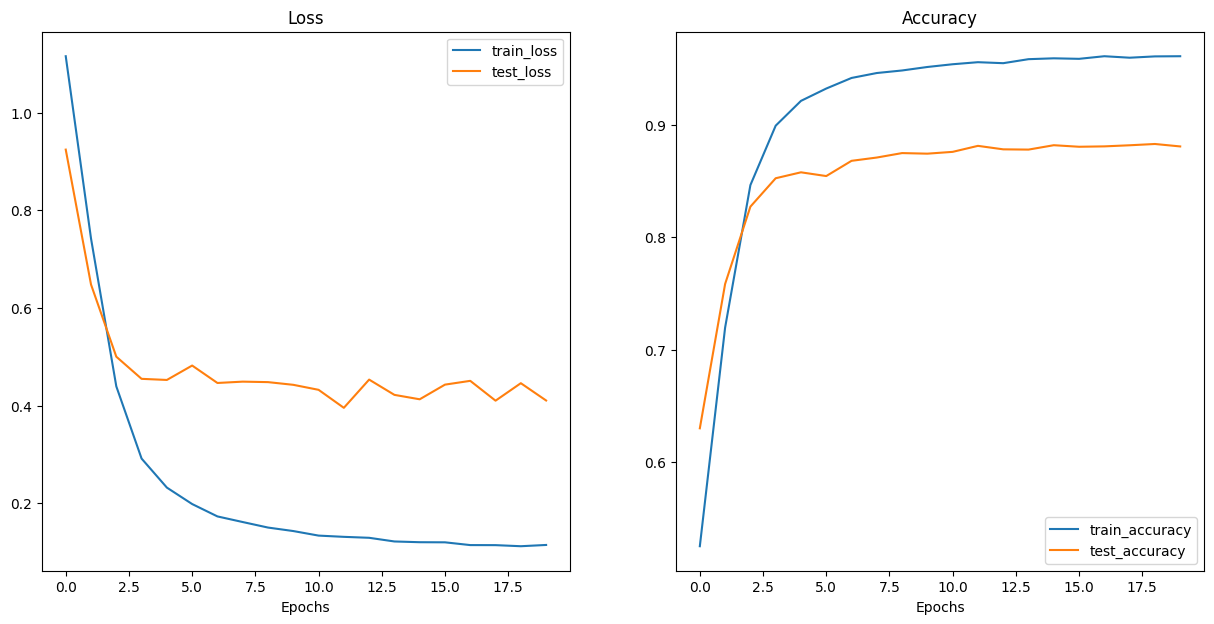

In [92]:
plot_loss_curves(model_results)

In [93]:
import torch

y_true = []
y_pred = []
y_prob = []

with torch.no_grad():
    for X_batch, y_batch in test_dataloader_custom :
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = model(X_batch)              # shape: (batch_size, num_classes)
        preds = torch.argmax(outputs, dim=1)  # predicted class index
        probs = torch.softmax(outputs, dim=1)
        
        y_true.extend(y_batch.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())
        y_prob.extend(probs.cpu().numpy())

In [94]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=label_encoder.classes_
    )
)


              precision    recall  f1-score   support

  Irrelevant       0.85      0.87      0.86      2949
    Negative       0.90      0.89      0.90      5255
     Neutral       0.90      0.86      0.88      4305
    Positive       0.86      0.89      0.87      4837

    accuracy                           0.88     17346
   macro avg       0.88      0.88      0.88     17346
weighted avg       0.88      0.88      0.88     17346



In [95]:

from sklearn.preprocessing import label_binarize


y_true = np.array(y_true)
y_scores = np.array(y_prob)

num_classes = 4
y_true_bin = label_binarize(y_true, classes=range(num_classes))

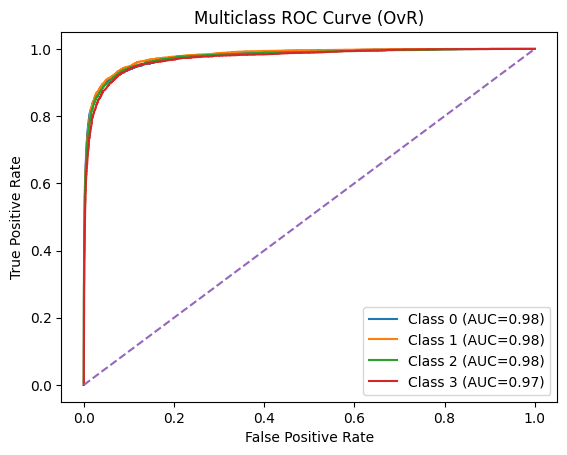

In [96]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure()

for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_scores[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve (OvR)")
plt.legend()
plt.show()
